# Previsione Spaziale dei Tempi di Attesa al Pronto Soccorso in un Bacino di Utenza dei Fornitori con PROC KRIGE2D

## Sintesi Esecutiva

Un team di network operations di un sistema sanitario misura il tempo medio di attesa al pronto soccorso (PS) (minuti) in ogni struttura attiva di un bacino di utenza metropolitano e vuole una superficie continua dei tempi di attesa per individuare le lacune di copertura per una nuova sede di pronto intervento. Questo notebook genera un insieme sintetico di **90 strutture geolocalizzate**, adatta un modello di **kriging ordinario** con un nugget, e interpola i tempi di attesa al PS su una griglia regolare che copre il bacino di 50 km x 50 km, producendo previsioni puntuali ed errori standard di kriging in ogni nodo della griglia e in tre ubicazioni candidate per il pronto intervento.

Nelle 90 strutture il tempo di attesa osservato ha una media di **35.5 minuti** (intervallo 7.5-58.7). La superficie kriged riproduce quel centro quasi esattamente (media dei nodi della griglia **35.55 minuti**) e varia da **16.1** nel tranquillo sud-est a **56.4** nel congestionato nord-ovest, dove i nodi con attesa prevista più alta si concentrano attorno al picco del centro città. Delle tre ubicazioni candidate per il pronto intervento, quella più vicina al centro città prevede l'attesa più alta (**52.2 +/- 7.3 minuti**), rendendola il caso di localizzazione con le prove più solide.

## Fonti dei Dati

Tutti i dati sono sintetici e generati inline nel primo blocco DATA (`call streaminit(20260531)`). Non vengono utilizzati file esterni o di rete.

| Dataset | Righe | Variabile | Tipo | Descrizione |
|---------|------|----------|------|-------------|
| `ed_sites` | 90 | `east` | Num | Coordinata est della struttura in km (0-50) all'interno della griglia del bacino metropolitano |
| `ed_sites` | 90 | `north` | Num | Coordinata nord della struttura in km (0-50) all'interno della griglia del bacino metropolitano |
| `ed_sites` | 90 | `site_id` | Char | Identificativo della struttura (es. `FAC037`) |
| `ed_sites` | 90 | `wait_min` | Num | Tempo medio di attesa al PS osservato in minuti; una superficie spazialmente correlata che combina un gradiente di congestione NO-SE, un picco del centro città e rumore locale |

## Previsione Spaziale dei Tempi di Attesa al PS con PROC KRIGE2D

Un sistema sanitario regionale gestisce **pronto soccorso e cliniche di pronto intervento** distribuiti su un bacino metropolitano di 50 km x 50 km. Ogni struttura riporta il proprio **tempo medio di attesa al PS** (minuti). I tempi di attesa sono spazialmente correlati: il centro urbano congestionato a nord-ovest registra valori alti, mentre le strutture periferiche a sud-est registrano valori più bassi. La pianificazione di rete vuole una superficie *continua* dei tempi di attesa, con incertezza, per individuare le lacune dove una nuova sede di pronto intervento allevierebbe maggiormente la pressione.

**PROC KRIGE2D** esegue il kriging ordinario bidimensionale: usa un modello di semivariogramma per interpolare i tempi di attesa misurati su una griglia di posizioni, restituendo sia una previsione sia un errore standard di kriging in ogni nodo. Faremo:

1. Generare un dataset sintetico realistico delle strutture.
2. Profilare la distribuzione osservata dei tempi di attesa.
3. Applicare il kriging con un modello sferico più nugget e ispezionare la superficie.
4. Prevedere direttamente in tre ubicazioni candidate per il pronto intervento.

## Passo 1 - Genera dati sintetici delle strutture

Distribuiamo 90 strutture uniformemente nel bacino. La superficie "vera" di tempi di attesa sottostante combina un trend regolare su larga scala (un gradiente di congestione da NO a SE più un rigonfiamento centrale del centro città vicino a (15, 38)) con un vortice regionale regolare, così che il campo sia genuinamente autocorrelato nello spazio e non puro rumore. Aggiungiamo un piccolo nugget di misurazione per imitare la variabilità di rendicontazione giorno per giorno.

In [1]:
DATI ed_sites;
   CHIAMARE streaminit(20260531);
   LUNGHEZZA site_id $6;
   FARE i = 1 FINO_A 90;
      east  = 50 * rand('uniform');
      north = 50 * rand('uniform');

      /* Trend di congestione su larga scala: alto nel nucleo del centro città NO,
         in diminuzione verso il margine periferico SE */
      trend = 18
            + 0.32 * (50 - east)
            + 0.28 * north;

      /* Picco centrale del centro città vicino a (15, 38) */
      dist2 = (east - 15)**2 + (north - 38)**2;
      surge = 22 * EXP(-dist2 / 160);

      /* Vortice regionale regolare per creare un'autocorrelazione realistica */
      eddy  = 6 * sin(east/9) * cos(north/11);

      /* Rumore locale di rendicontazione (nugget di misurazione) */
      noise = 4 * rand('normal');

      wait_min = round(trend + surge + eddy + noise, 0.1);
      SE_COND wait_min < 3 ALLORA wait_min = 3;

      site_id = cats('FAC', PUT(i, z3.));
      USCITA;
   FINE;
   MANTENERE site_id east north wait_min;
ESEGUIRE;

PROCEDURA STAMPARE DATI=ed_sites(obs=10) noobs ETICHETTA;
   ETICHETTA site_id='ID Struttura' east='Est (km)' north='Nord (km)' wait_min='Attesa (min)';
   TITOLO 'Prime 10 Strutture PS Sintetiche (coordinate in km, attesa in minuti)';
   VARIABILE site_id east north wait_min;
ESEGUIRE;

                         Prime 10 Strutture PS Sintetiche (coordinate in km, attesa in minuti)                          

ID Struttura       Est (km)      Nord (km)  Attesa (min)
FAC001        42.1064239035  44.8746335392          36.7
FAC002        10.6189061789  14.5101311244          36.2
FAC003        48.9064287162    18.61727984          17.7
FAC004         45.555283186   43.264675772          34.5
FAC005        32.9816533373  24.7120124541          32.5
FAC006        31.1796232687  19.1168441231          31.4
FAC007        34.6664652019  35.2149577448          39.2
FAC008        40.5104234712   2.9588781811          17.1
FAC009         9.9213354522  40.5368804705          54.3
FAC010        24.5041747799  22.5897811072          35.9

... 80 more observations (showing 10 of 90)




NOTE: DATA ed_sites


NOTE: Wrote ed_sites (90 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC PRINT data=ed_sites

NOTE: PROC PRINT completed: 10 observations printed, 4 variables


## Passo 2 - Profila i tempi di attesa osservati

Prima del kriging, verifica che la superficie sia distribuita in modo sensato. Un rapido riepilogo `PROC MEANS` fornisce l'intervallo e la tendenza centrale che la superficie kriged dovrebbe riprodurre. Le 90 strutture hanno una media di **35.5 minuti** con una deviazione standard di **10.6**, che va da **7.5** nella struttura periferica più tranquilla a **58.7** nella struttura del centro città più congestionata - un intervallo ampio e realistico per un target di interpolazione.

In [2]:
PROCEDURA MEDIE DATI=ed_sites n mean std MIN p25 MEDIAN p75 MAX maxdec=1;
   TITOLO 'Distribuzione Osservata dei Tempi di Attesa al PS tra le Strutture';
   VARIABILE wait_min;
   ETICHETTA wait_min='Attesa (min)';
ESEGUIRE;

                           Distribuzione Osservata dei Tempi di Attesa al PS tra le Strutture                           

                                                  The MEANS Procedure

 Variable  Label               N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 -----------------------------------------------------------------------------------------------------------------------------
 wait_min  Attesa (min)       90        35.5        10.6         7.5             29.1        35.7             39.5        58.7
 -----------------------------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Passo 3 - Kriging ordinario con un modello sferico

L'istruzione `COORDINATES` indica gli assi spaziali, `PREDICT VAR=` indica la variabile di analisi e imposta il vicinato di ricerca, e `MODEL` fornisce il semivariogramma. Usiamo una forma **sferica** (una scelta standard quando la correlazione si azzera a un raggio finito), con:

- `SCALE=120` - la soglia parziale (varianza spiegata dalla struttura spaziale),
- `RANGE=18` - la correlazione raggiunge il livello di fondo a circa 18 km,
- `NUGGET=14` - la discontinuità di misurazione/rendicontazione a distanza zero.

Interpoliamo su un reticolo regolare di **9 x 9 = 81 nodi** che copre l'intero bacino (`GRID X=0 TO 50 BY 6 Y=0 TO 50 BY 6`) - abbastanza grezzo da riassumere e classificare ogni nodo direttamente, abbastanza fine da mappare la struttura. `OUTEST=` cattura le previsioni e gli errori standard sulla griglia; `OUTNBHD=` registra quante strutture sono entrate in ciascuna risoluzione locale. `PLOTS=` richiede la mappa dei dati osservati e il contour della previsione colorato per errore standard.

                           Distribuzione Osservata dei Tempi di Attesa al PS tra le Strutture                           

   The KRIGE2D Procedure    
     Model Information      

Item                   Value
-----------------  ---------
Variogram Model    SPHERICAL
Kriging Method      ORDINARY
Observations Used         90
Prediction Points         81




NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote krige_sph (81 rows, 4 columns).


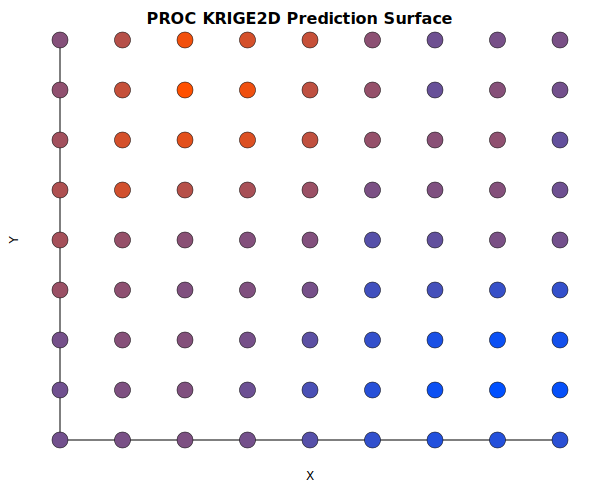

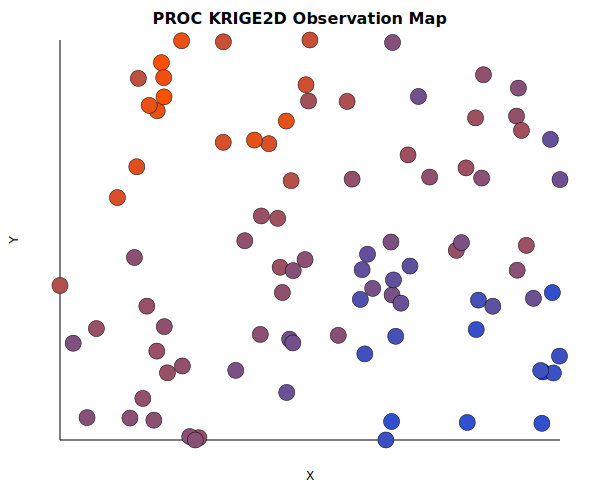

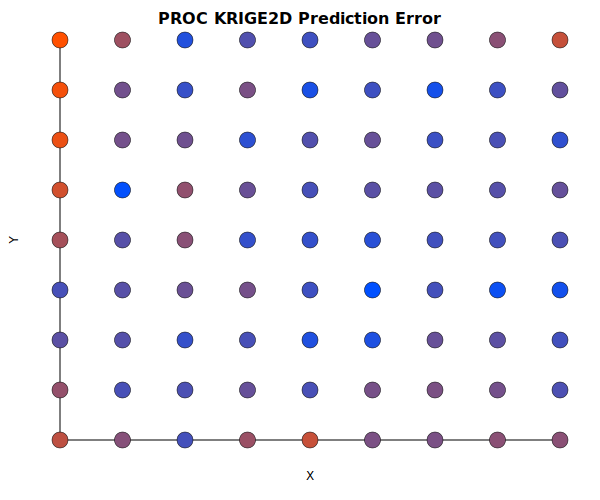

In [3]:
PROCEDURA krige2d DATI=ed_sites outest=krige_sph outnbhd=nbhd_sph
      PLOTS(only)=(observations prediction(fill=pred line=se));
   TITOLO 'Kriging Ordinario dei Tempi di Attesa al PS - Modello Sferico';
   COORDINATES XC=east YC=north;
   predict VARIABILE=wait_min radius=20 minpoints=10 maxpoints=40;
   MODELLO FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=0 FINO_A 50 PER 6 y=0 FINO_A 50 PER 6;
ESEGUIRE;

## Passo 4 - Ispeziona la superficie kriged

Il dataset `OUTEST=` contiene una riga per nodo della griglia con il tempo di attesa previsto (`estimate`) e il suo errore standard di kriging (`stderr`). Riassumiamo la superficie e segnaliamo i nodi previsti più caldi - zone candidate dove una nuova sede di pronto intervento allevierebbe maggiormente la pressione.

La media della superficie kriged (**35.55 minuti**) segue quasi esattamente la media osservata delle strutture (35.5), una verifica di coerenza che il kriging ordinario è non distorto. Le previsioni vanno da **16.1** nel rado sud-est a **56.4** nel congestionato nord-ovest; gli errori standard vanno da **5.1** dove le strutture sono dense a **11.2** negli angoli campionati scarsamente. I sei nodi più caldi si trovano tutti nel quadrante NO attorno a (12-18, 36-48), esattamente sul picco del centro città incorporato nei dati.

In [4]:
PROCEDURA MEDIE DATI=krige_sph n mean MIN MAX maxdec=2;
   TITOLO 'Riepilogo della Superficie Kriged (Attesa Prevista in Minuti ed Errore Standard)';
   VARIABILE estimate stderr;
   ETICHETTA estimate='Attesa Prevista (min)' stderr='Errore Standard';
ESEGUIRE;

PROCEDURA ORDINARE DATI=krige_sph out=hot_nodes;
   PER DISCENDENTE estimate;
ESEGUIRE;

PROCEDURA STAMPARE DATI=hot_nodes(obs=6) noobs ETICHETTA;
   TITOLO 'Sei Nodi della Griglia con i Tempi di Attesa PS Previsti Più Alti';
   VARIABILE x y estimate stderr;
   ETICHETTA x='Est (km)' y='Nord (km)' estimate='Attesa Prevista (min)' stderr='Errore Standard';
ESEGUIRE;

                    Riepilogo della Superficie Kriged (Attesa Prevista in Minuti ed Errore Standard)                    

                                                  The MEANS Procedure

 Variable  Label                        N        Mean     Minimum     Maximum
 ----------------------------------------------------------------------------
 ESTIMATE  Attesa Prevista (min)       81       35.55       16.07       56.38
 STDERR    Errore Standard             81        7.38        5.06       11.20
 ----------------------------------------------------------------------------

                           Sei Nodi della Griglia con i Tempi di Attesa PS Previsti Più Alti                            

Est (km)  Nord (km)  Attesa Prevista (min)  Errore Standard
      12         42          56.3838526129     6.3860887297
      12         48           54.379464215      5.876759721
      18         42            53.81777091     8.0028060667
      12         36          51.9499223116     7.72830


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=krige_sph

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 81 rows from krige_sph.
NOTE: Wrote hot_nodes (81 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=hot_nodes

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


## Passo 5 - Prevedi in sedi candidate specifiche

La pianificazione di rete ha tre ubicazioni proposte per il pronto intervento. Eseguiamo il kriging direttamente in ciascun punto fornendolo come una griglia a nodo singolo (`GRID X=cx TO cx BY 1 Y=cy TO cy BY 1`), fornendo ai pianificatori il tempo di attesa previsto e il suo errore standard di kriging nella coordinata esatta.

Il candidato vicino al centro città, **(14, 37)**, restituisce l'attesa prevista più alta - **52.2 +/- 7.3 minuti** - confermando che assorbirebbe la domanda dai PS più affollati. Il candidato a sud-est **(32, 12)** si trova nel tranquillo angolo periferico a **22.0 +/- 6.2**, e il candidato a nord-est **(42, 44)** si colloca nella fascia media a **36.4 +/- 5.9**. Sulla sola base dell'attesa prevista, il candidato del centro città è il caso di localizzazione con le prove più solide.

In [5]:
PROCEDURA krige2d DATI=ed_sites outest=cand_dt PLOTS=none;
   TITOLO 'Candidato A - Centro Città (14, 37)';
   COORDINATES XC=east YC=north;
   predict VARIABILE=wait_min radius=20 minpoints=8 maxpoints=40;
   MODELLO FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=14 FINO_A 14 PER 1 y=37 FINO_A 37 PER 1;
ESEGUIRE;

PROCEDURA krige2d DATI=ed_sites outest=cand_se PLOTS=none;
   TITOLO 'Candidato B - Periferia Sud-Est (32, 12)';
   COORDINATES XC=east YC=north;
   predict VARIABILE=wait_min radius=20 minpoints=8 maxpoints=40;
   MODELLO FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=32 FINO_A 32 PER 1 y=12 FINO_A 12 PER 1;
ESEGUIRE;

PROCEDURA krige2d DATI=ed_sites outest=cand_ne PLOTS=none;
   TITOLO 'Candidato C - Margine Nord-Est (42, 44)';
   COORDINATES XC=east YC=north;
   predict VARIABILE=wait_min radius=20 minpoints=8 maxpoints=40;
   MODELLO FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=42 FINO_A 42 PER 1 y=44 FINO_A 44 PER 1;
ESEGUIRE;

DATI candidates;
   IMPOSTARE cand_dt cand_se cand_ne;
ESEGUIRE;

PROCEDURA STAMPARE DATI=candidates noobs ETICHETTA;
   TITOLO 'Tempi di Attesa PS Previsti in Tre Sedi Candidate per il Pronto Intervento';
   VARIABILE x y estimate stderr;
   ETICHETTA x='Est (km)' y='Nord (km)' estimate='Attesa Prevista (min)' stderr='Errore Standard';
ESEGUIRE;

                           Sei Nodi della Griglia con i Tempi di Attesa PS Previsti Più Alti                            

   The KRIGE2D Procedure    
     Model Information      

Item                   Value
-----------------  ---------
Variogram Model    SPHERICAL
Kriging Method      ORDINARY
Observations Used         90
Prediction Points          1

          Kriging Predictions          

       X         Y  Estimate  Std Error
--------  --------  --------  ---------
   14.00     37.00   52.1916     7.2579

                           Sei Nodi della Griglia con i Tempi di Attesa PS Previsti Più Alti                            

   The KRIGE2D Procedure    
     Model Information      

Item                   Value
-----------------  ---------
Variogram Model    SPHERICAL
Kriging Method      ORDINARY
Observations Used         90
Prediction Points          1

          Kriging Predictions          

       X         Y  Estimate  Std Error
--------  --------  --------  ---------
   32


NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote cand_dt (1 rows, 4 columns).
NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote cand_se (1 rows, 4 columns).
NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote cand_ne (1 rows, 4 columns).
NOTE: DATA candidates


NOTE: Read 1 rows from cand_dt.
NOTE: Read 2 rows from cand_se.
NOTE: Read 3 rows from cand_ne.
NOTE: Wrote candidates (3 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=candidates

NOTE: PROC PRINT completed: 3 observations printed, 4 variables


## Interpretazione dei risultati

- **La superficie kriged riproduce la struttura di congestione del bacino.** Il modello di kriging ordinario sferico interpola un campo regolare dei tempi di attesa la cui media sui nodi della griglia (35.55 min) corrisponde alla media osservata delle strutture (35.5 min), con le attese previste più alte - fino a 56.4 minuti - concentrate nel quadrante NO attorno al picco del centro città vicino a (15, 38) che abbiamo incorporato nei dati sintetici. Questa corrispondenza è una verifica di coerenza che il modello si comporta correttamente.
- **Gli errori standard localizzano la fiducia.** L'errore standard di kriging va da 5.1 minuti dove le strutture sono dense a 11.2 negli angoli scarsamente campionati del bacino. I pianificatori dovrebbero trattare le previsioni nelle zone con `stderr` alto con cautela; quelle sono anche le aree dove aggiungere una struttura migliorerebbe maggiormente sia la copertura futura sia la misurazione futura.
- **Le previsioni puntuali supportano le decisioni di localizzazione.** Il kriging delle tre ubicazioni candidate direttamente trasforma la superficie in una tabella utilizzabile. Il candidato del centro città (14, 37) mostra l'attesa prevista più alta (52.2 min) con un errore standard moderato (7.3), rendendolo il caso di localizzazione con le prove più solide per una nuova sede di pronto intervento che alleggerisca il PS più affollato; il candidato periferico a sud-est (32, 12) si trova in un angolo a bassa domanda (22.0 min) e il candidato al margine nord-est (42, 44) si colloca nella fascia media (36.4 min).

In pratica i parametri del semivariogramma (`SCALE`, `RANGE`, `NUGGET`) sarebbero stimati empiricamente con PROC VARIOGRAM e poi passati a KRIGE2D - sia come valori espliciti come mostrato qui, sia automaticamente tramite `RESTORE` da un item store di VARIOGRAM.